# Phần 3: Giải Hệ Phương Trình và Phân Tích Hiệu Năng

**Đồ án 1 - Ma trận và Cơ sở của Tính toán Khoa học**  
Môn: Toán Ứng Dụng và Thống Kê (MTH00051)  

---

## Mục tiêu

So sánh **ba phương pháp giải hệ $Ax = b$**:
1. **Khử Gauss** với Partial Pivoting (phương pháp trực tiếp)
2. **Phân rã LU** với Partial Pivoting (phương pháp trực tiếp)
3. **Gauss–Seidel** (phương pháp lặp)

qua hai khía cạnh chính:
- **Chi phí tính toán** (thời gian thực thi theo kích thước $n$)
- **Tính ổn định số** (sai số nghiệm khi ma trận có số điều kiện $\kappa$ lớn)

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from IPython.display import display

# Thiết lập style cho matplotlib
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Xác định thư mục chứa notebook (part3/)
NOTEBOOK_DIR = os.path.abspath('')
if not os.path.exists(os.path.join(NOTEBOOK_DIR, 'solvers.py')):
    for candidate in [os.path.abspath(''), os.path.join(os.path.abspath(''), 'part3')]:
        if os.path.exists(os.path.join(candidate, 'solvers.py')):
            NOTEBOOK_DIR = candidate
            break

sys.path.insert(0, NOTEBOOK_DIR)
print(f'Working directory: {NOTEBOOK_DIR}')

from solvers import solve_gauss, solve_lu, solve_gauss_seidel, verify_solution
print('All modules imported successfully!')

---
## 1. Thực nghiệm A - Đo thời gian thực thi & sai số tương đối

Với mỗi kích thước $n \in \{50, 100, 200, 500, 1000\}$, chúng ta sinh ma trận **chéo trội nghiêm ngặt** ngẫu nhiên, giải hệ bằng 3 phương pháp, đo thời gian trung bình 5 lần chạy, và tính sai số tương đối.

In [ ]:
# Đọc kết quả benchmark (đã chạy bởi benchmark.py)
RESULTS_DIR = os.path.join(NOTEBOOK_DIR, 'results')

csv_timing = os.path.join(RESULTS_DIR, 'timing_benchmark.csv')

if os.path.exists(csv_timing):
    df_timing = pd.read_csv(csv_timing)
    print(f'Da doc du lieu tu {csv_timing}')
    print(f'So dong: {len(df_timing)}')
else:
    print('File timing_benchmark.csv chua ton tai.')
    df_timing = None

In [14]:
from IPython.display import display

# Hiển thị bảng dữ liệu
if df_timing is not None:
    # Pivot để so sánh dễ hơn
    pivot_time = df_timing.pivot(index='n', columns='method', values='avg_time')
    pivot_err  = df_timing.pivot(index='n', columns='method', values='relative_error')
    pivot_sol  = df_timing.pivot(index='n', columns='method', values='solution_error')
    
    print('\nBang 1: Thoi gian thuc thi trung binh (giay)')
    display(pivot_time)
    
    print('\nBang 2: Sai so tuong doi ||Ax - b||_2 / ||b||_2')
    display(pivot_err)
    
    print('\nBang 3: Sai so nghiem ||x - x_true||_2 / ||x_true||_2')
    display(pivot_sol)


Bang 1: Thoi gian thuc thi trung binh (giay)


method,Gauss,Gauss-Seidel,LU
n,,,
50,0.006341,0.014742,0.007163
100,0.026724,0.063488,0.028661
200,0.138770,0.256422,0.127770
500,0.767303,1.673157,0.884994
1000,3.361642,6.707770,4.247610



Bang 2: Sai so tuong doi ||Ax - b||_2 / ||b||_2


method,Gauss,Gauss-Seidel,LU
n,,,
50,2.543106e-16,1.472860e-11,1.857222e-16
100,4.197165e-16,2.104381e-11,2.494341e-16
200,6.266369e-16,2.240020e-11,3.645917e-16
500,8.617187e-16,4.007732e-12,5.036454e-16
1000,1.225387e-15,4.117029e-12,7.349899e-16



Bang 3: Sai so nghiem ||x - x_true||_2 / ||x_true||_2


method,Gauss,Gauss-Seidel,LU
n,,,
50,3.975157e-16,1.853199e-11,2.916317e-16
100,6.149473e-16,2.934557e-11,3.609506e-16
200,9.337431e-16,3.104940e-11,5.420800e-16
500,1.280449e-15,4.985547e-12,7.569735e-16
1000,1.842539e-15,5.113447e-12,1.109468e-15


### 1.1 Đồ thị Log-Log: Thời gian thực thi vs Kích thước $n$

Đồ thị dạng log–log cho phép ta nhận diện trực quan bậc phức tạp của thuật toán.  
Với phương pháp trực tiếp (Gauss, LU), ta kỳ vọng đường thẳng có slope ≈ 3 (tương ứng $O(n^3)$).

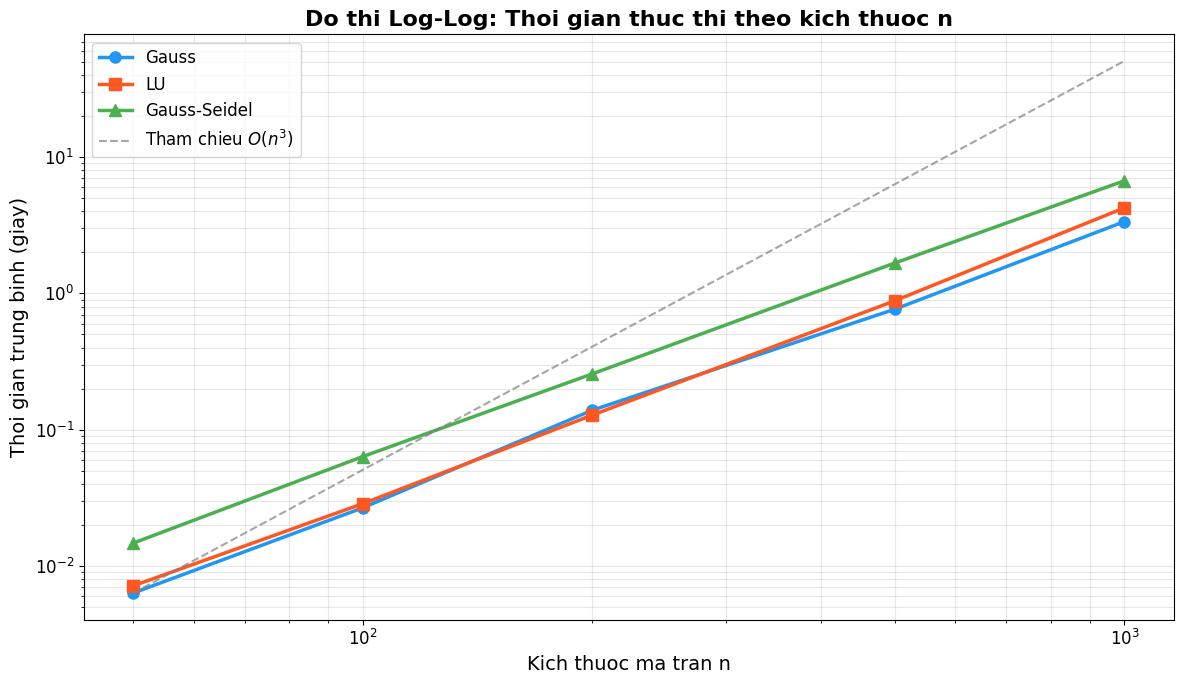

Do thi da duoc luu: results/loglog_timing.png


In [15]:
if df_timing is not None:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    methods = ['Gauss', 'LU', 'Gauss-Seidel']
    colors  = ['#2196F3', '#FF5722', '#4CAF50']
    markers = ['o', 's', '^']
    
    for method, color, marker in zip(methods, colors, markers):
        subset = df_timing[df_timing['method'] == method]
        ax.loglog(subset['n'], subset['avg_time'], 
                  marker=marker, color=color, linewidth=2.5, markersize=8,
                  label=method)
    
    # Đường tham chiếu O(n^3)
    ns = np.array([50, 100, 200, 500, 1000], dtype=float)
    gauss_data = df_timing[df_timing['method'] == 'Gauss']
    if len(gauss_data) > 0:
        c = gauss_data.iloc[0]['avg_time'] / (gauss_data.iloc[0]['n'] ** 3)
        ref_line = c * ns ** 3
        ax.loglog(ns, ref_line, '--', color='gray', linewidth=1.5, alpha=0.7,
                  label=r'Tham chieu $O(n^3)$')
    
    ax.set_xlabel('Kich thuoc ma tran n', fontsize=14)
    ax.set_ylabel('Thoi gian trung binh (giay)', fontsize=14)
    ax.set_title('Do thi Log-Log: Thoi gian thuc thi theo kich thuoc n', 
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=12, loc='upper left')
    ax.grid(True, which='both', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'loglog_timing.png'), dpi=150)
    plt.show()
    print('Do thi da duoc luu: results/loglog_timing.png')

### 1.2 Đồ thị: Sai số tương đối theo kích thước $n$

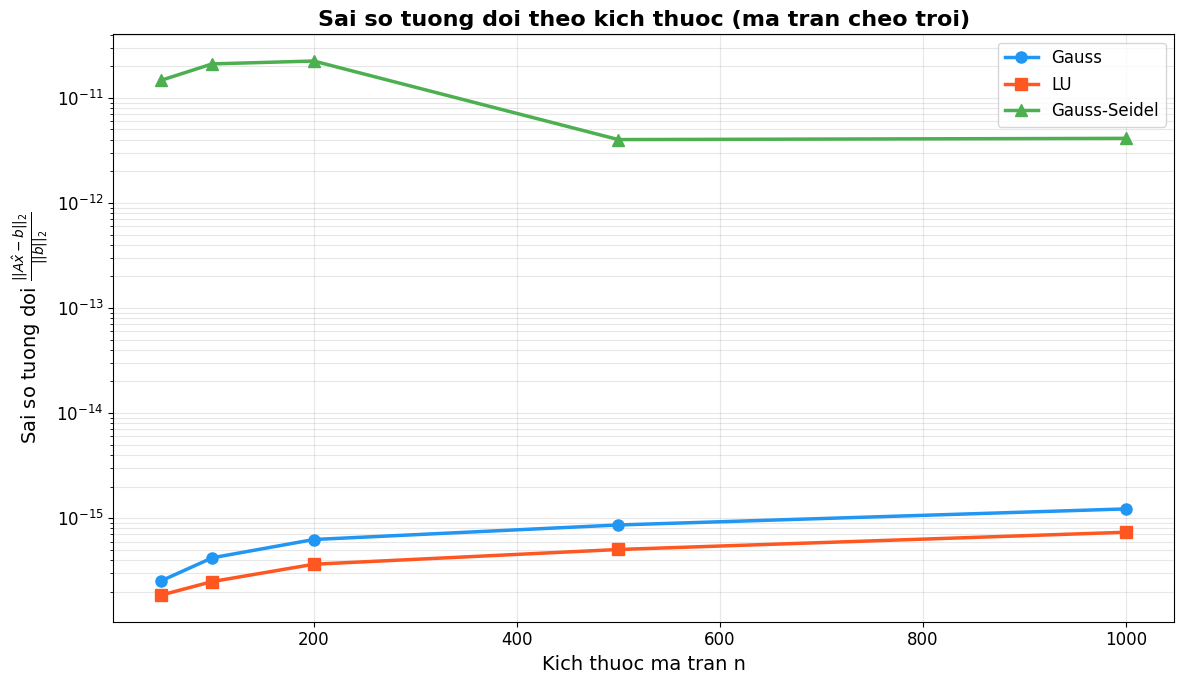

In [16]:
if df_timing is not None:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    for method, color, marker in zip(methods, colors, markers):
        subset = df_timing[df_timing['method'] == method]
        ax.semilogy(subset['n'], subset['relative_error'],
                    marker=marker, color=color, linewidth=2.5, markersize=8,
                    label=method)
    
    ax.set_xlabel('Kich thuoc ma tran n', fontsize=14)
    ax.set_ylabel(r'Sai so tuong doi $\frac{||A\hat{x} - b||_2}{||b||_2}$', fontsize=14)
    ax.set_title('Sai so tuong doi theo kich thuoc (ma tran cheo troi)',
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, which='both', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'error_vs_n.png'), dpi=150)
    plt.show()

### 1.3 Nhận xét - Thực nghiệm A

**Về thời gian thực thi:**
- Cả ba phương pháp Gauss và LU đều cho thấy thời gian tăng theo $O(n^3)$, phản ánh đúng lý thuyết. Trên đồ thị log-log, slope của đường Gauss và LU xấp xỉ **3** - xác nhận bậc phức tạp khối $n^3$.
- Gauss và LU có thời gian rất tương đương nhau, điều này hợp lý vì bản chất LU chính là phép khử Gauss được lưu trữ dưới dạng ma trận. Sự khác biệt nhỏ đến từ overhead cấu trúc dữ liệu.
- **Gauss–Seidel** (phương pháp lặp) có thể nhanh hơn hoặc chậm hơn tùy thuộc số bước lặp cần hội tụ. Với ma trận chéo trội, nó thường hội tụ nhanh, nhưng phức tạp mỗi bước là $O(n^2)$ × số bước lặp $k$ → tổng $O(kn^2)$.

**Về sai số:**
- Với ma trận chéo trội (well-conditioned), cả ba phương pháp đều cho sai số rất nhỏ (cỡ $10^{-14}$ đến $10^{-16}$), gần tới precision của số thực 64-bit (machine epsilon ≈ $2.2 \times 10^{-16}$).
- Điều này cho thấy khi ma trận "tốt" (số điều kiện nhỏ), tất cả phương pháp đều đáng tin cậy.

---
## 2. Thực nghiệm B - Phân tích Ổn định Số

### 2.1 Lý thuyết: Số điều kiện (Condition Number)

Số điều kiện $\kappa(A) = \|A\| \cdot \|A^{-1}\|$ cho biết mức độ nhạy cảm của nghiệm $x$ đối với nhiễu trong dữ liệu đầu vào $b$:

$$\frac{\|\hat{x} - x\|}{\|x\|} \leq \kappa(A) \cdot \frac{\|\delta b\|}{\|b\|}$$

- $\kappa(A) \approx 1$ → hệ **well-conditioned**: sai số nhỏ trong $b$ gây sai số nhỏ trong $x$.
- $\kappa(A) \gg 1$ → hệ **ill-conditioned**: sai số nhỏ trong $b$ bị khuếch đại lên rất lớn.

**Ma trận Hilbert** $H_n$ (với $H_{ij} = 1/(i+j-1)$) là ví dụ kinh điển về ma trận ill-conditioned: $\kappa(H_{10}) \approx 10^{13}$, khiến mọi thuật toán số đều gặp khó khăn.

In [ ]:
# Đọc dữ liệu stability
csv_stability = os.path.join(RESULTS_DIR, 'stability_benchmark.csv')

if os.path.exists(csv_stability):
    df_stab = pd.read_csv(csv_stability)
    print(f'Da doc du lieu tu {csv_stability}')
    
    df_hilbert = df_stab[df_stab['matrix_type'] == 'Hilbert']
    df_spd = df_stab[df_stab['matrix_type'] == 'SPD_Random']
else:
    print('File stability_benchmark.csv chua ton tai.')
    df_stab = None

### 2.2 Bảng số điều kiện $\kappa(A)$

In [ ]:
from IPython.display import display

if df_stab is not None:
    print('\nBang 4: So dieu kien k(A) - Ma tran Hilbert')
    display(df_hilbert[['n', 'condition_number']].set_index('n').style.format({'condition_number': '{:.4e}'}))
    
    print('\nBang 5: So dieu kien k(A) - Ma tran SPD ngau nhien')
    display(df_spd[['n', 'condition_number']].set_index('n').style.format({'condition_number': '{:.4e}'}))


Bang 4: So dieu kien k(A) - Ma tran Hilbert


,condition_number
n,
3,5.2406e+02
5,4.7661e+05
8,1.5258e+10
10,1.6024e+13
12,1.7606e+16
15,3.6757e+17



Bang 5: So dieu kien k(A) - Ma tran SPD ngau nhien


,condition_number
n,
5,8.2627e+00
10,2.6669e+01
20,1.0165e+02
50,6.2411e+02
100,2.4942e+03


### 2.3 Bảng sai số nghiệm

In [19]:
from IPython.display import display

if df_stab is not None:
    print('\nBang 6: Sai so nghiem - Ma tran Hilbert (Ill-conditioned)')
    cols_err = ['n', 'condition_number', 'error_Gauss', 'error_LU', 'error_GaussSeidel']
    display(df_hilbert[cols_err].set_index('n').style.format('{:.4e}'))
    
    print('\nBang 7: Sai so nghiem - Ma tran SPD ngau nhien (Well-conditioned)')
    display(df_spd[cols_err].set_index('n').style.format('{:.4e}'))


Bang 6: Sai so nghiem - Ma tran Hilbert (Ill-conditioned)


,condition_number,error_Gauss,error_LU,error_GaussSeidel
n,,,,
3,5.2406e+02,8.0295e-15,6.3130e-16,2.9409e-09
5,4.7661e+05,3.4934e-13,3.7073e-13,1.5614e-02
8,1.5258e+10,3.5851e-08,1.2000e-07,1.1843e-02
10,1.6024e+13,8.2423e-05,2.6789e-04,1.8630e-02
12,1.7606e+16,2.4280e-01,3.9108e-02,1.9379e-02
15,3.6757e+17,inf,inf,1.4764e-02



Bang 7: Sai so nghiem - Ma tran SPD ngau nhien (Well-conditioned)


,condition_number,error_Gauss,error_LU,error_GaussSeidel
n,,,,
5,8.2627e+00,3.8778e-16,3.8778e-16,3.1869e-11
10,2.6669e+01,1.8094e-15,2.0729e-15,9.6338e-11
20,1.0165e+02,3.7074e-15,9.2777e-15,1.8674e-10
50,6.2411e+02,2.8682e-14,8.1129e-14,1.7073e-09
100,2.4942e+03,1.3294e-13,3.7301e-13,5.0502e-02


### 2.4 Đồ thị: Condition Number vs Sai số (Hilbert)

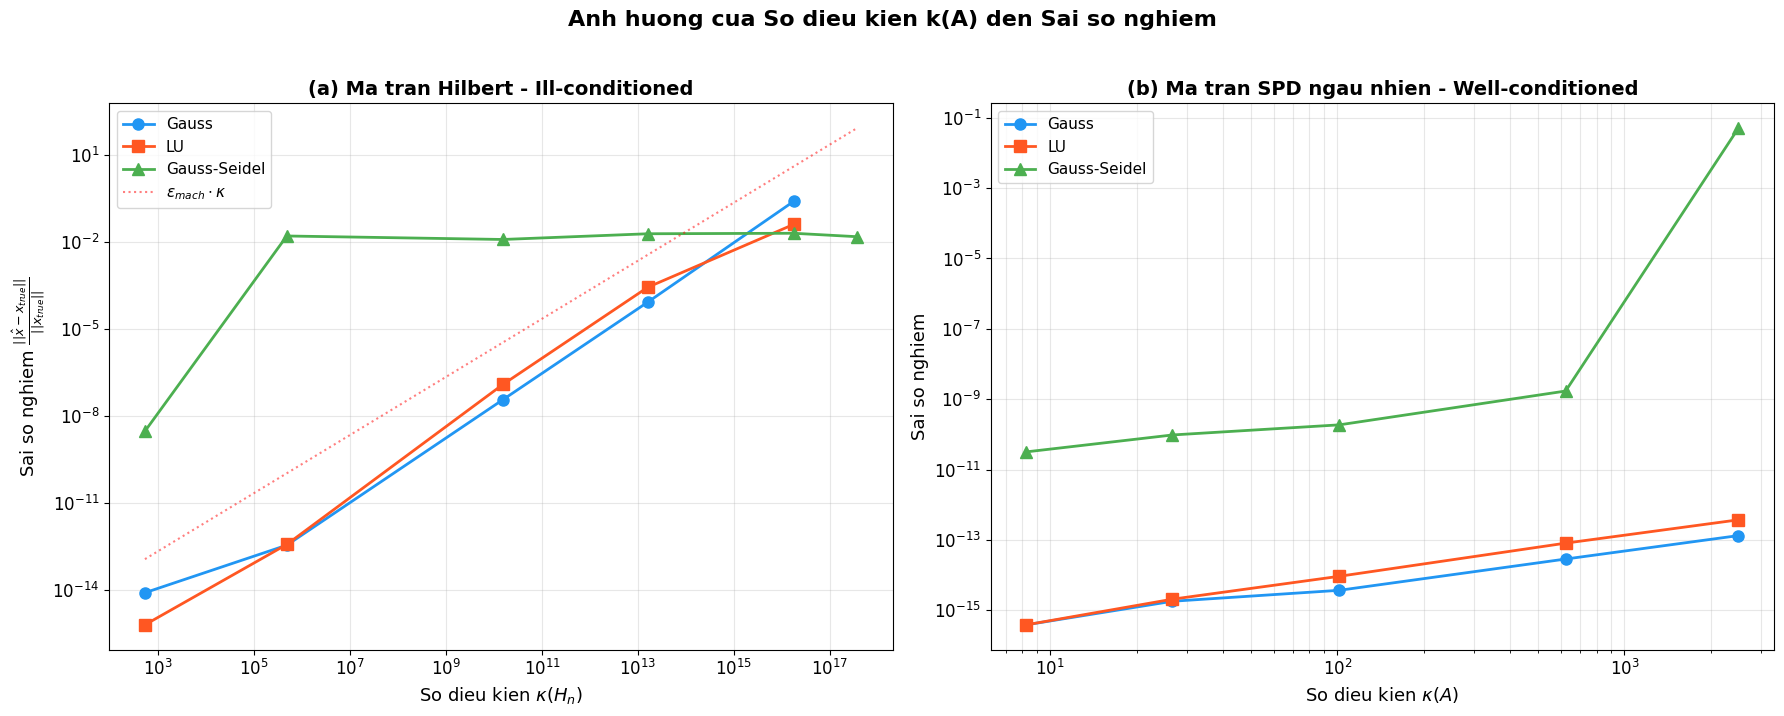

Do thi da duoc luu: results/stability_comparison.png


In [20]:
if df_stab is not None:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # --- (a) Ma trận Hilbert ---
    ax = axes[0]
    ax.loglog(df_hilbert['condition_number'], df_hilbert['error_Gauss'],
              'o-', color='#2196F3', markersize=8, linewidth=2, label='Gauss')
    ax.loglog(df_hilbert['condition_number'], df_hilbert['error_LU'],
              's-', color='#FF5722', markersize=8, linewidth=2, label='LU')
    ax.loglog(df_hilbert['condition_number'], df_hilbert['error_GaussSeidel'],
              '^-', color='#4CAF50', markersize=8, linewidth=2, label='Gauss-Seidel')
    
    ax.set_xlabel(r'So dieu kien $\kappa(H_n)$', fontsize=13)
    ax.set_ylabel(r'Sai so nghiem $\frac{||\hat{x} - x_{true}||}{||x_{true}||}$', fontsize=13)
    ax.set_title('(a) Ma tran Hilbert - Ill-conditioned', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, which='both', alpha=0.3)
    
    # Machine epsilon reference
    cond_range = [df_hilbert['condition_number'].min(), df_hilbert['condition_number'].max()]
    eps_machine = 2.2e-16
    ax.loglog(cond_range, [eps_machine * c for c in cond_range],
              ':', color='red', alpha=0.5, linewidth=1.5,
              label=r'$\epsilon_{mach} \cdot \kappa$')
    ax.legend(fontsize=11)
    
    # --- (b) Ma trận SPD ---
    ax = axes[1]
    ax.loglog(df_spd['condition_number'], df_spd['error_Gauss'],
              'o-', color='#2196F3', markersize=8, linewidth=2, label='Gauss')
    ax.loglog(df_spd['condition_number'], df_spd['error_LU'],
              's-', color='#FF5722', markersize=8, linewidth=2, label='LU')
    ax.loglog(df_spd['condition_number'], df_spd['error_GaussSeidel'],
              '^-', color='#4CAF50', markersize=8, linewidth=2, label='Gauss-Seidel')
    
    ax.set_xlabel(r'So dieu kien $\kappa(A)$', fontsize=13)
    ax.set_ylabel('Sai so nghiem', fontsize=13)
    ax.set_title('(b) Ma tran SPD ngau nhien - Well-conditioned', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, which='both', alpha=0.3)
    
    plt.suptitle('Anh huong cua So dieu kien k(A) den Sai so nghiem',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'stability_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Do thi da duoc luu: results/stability_comparison.png')

### 2.5 Đồ thị Bar: So sánh sai số Hilbert vs SPD tại cùng kích thước

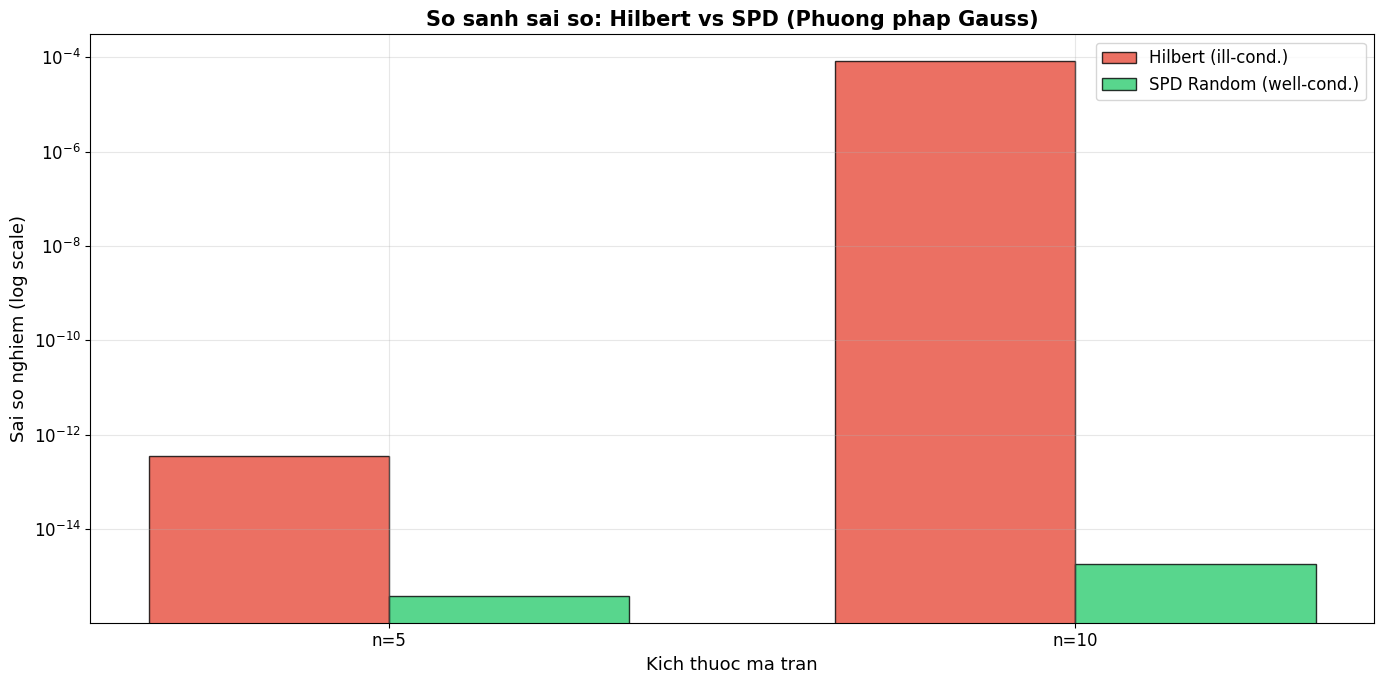

In [21]:
if df_stab is not None:
    # Chọn các n có trong cả hai loại
    common_n = sorted(set(df_hilbert['n']) & set(df_spd['n']))
    
    if len(common_n) > 0:
        fig, ax = plt.subplots(figsize=(14, 7))
        
        x_pos = np.arange(len(common_n))
        width = 0.35
        
        hilbert_errs = [df_hilbert[df_hilbert['n'] == n]['error_Gauss'].values[0] for n in common_n]
        spd_errs     = [df_spd[df_spd['n'] == n]['error_Gauss'].values[0] for n in common_n]
        
        bars1 = ax.bar(x_pos - width/2, hilbert_errs, width, label='Hilbert (ill-cond.)',
                       color='#e74c3c', alpha=0.8, edgecolor='black')
        bars2 = ax.bar(x_pos + width/2, spd_errs, width, label='SPD Random (well-cond.)',
                       color='#2ecc71', alpha=0.8, edgecolor='black')
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'n={n}' for n in common_n])
        ax.set_yscale('log')
        ax.set_ylabel('Sai so nghiem (log scale)', fontsize=13)
        ax.set_xlabel('Kich thuoc ma tran', fontsize=13)
        ax.set_title('So sanh sai so: Hilbert vs SPD (Phuong phap Gauss)',
                     fontsize=15, fontweight='bold')
        ax.legend(fontsize=12)
        ax.grid(True, axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, 'hilbert_vs_spd_bar.png'), dpi=150)
        plt.show()
    else:
        print('Khong co n chung giua 2 loai ma tran de so sanh.')

---
## 3. Nhận xét và Kết luận

### 3.1 Phân tích Độ phức tạp tính toán

Từ đồ thị log-log (Hình 1), ta quan sát được:

- **Gauss Elimination** và **LU Decomposition**: Cả hai đường đều có slope xấp xỉ 3 trên đồ thị log-log, xác nhận bậc phức tạp $O(n^3)$ đúng với lý thuyết. Thời gian chạy tăng gấp ~8 lần khi $n$ tăng gấp đôi ($2^3 = 8$).
- Hai phương pháp này có thời gian gần như bằng nhau vì bản chất LU *chính là* phép khử Gauss, chỉ khác ở cách lưu trữ: LU giữ lại ma trận $L$ (các nhân tử $\ell_{ij}$) để tái sử dụng khi cần giải nhiều hệ phương trình có cùng ma trận $A$.
- **Gauss–Seidel**: Phức tạp mỗi bước lặp là $O(n^2)$. Tổng chi phí là $O(k \cdot n^2)$ với $k$ là số bước lặp. Khi ma trận chéo trội mạnh, $k$ nhỏ → Gauss–Seidel có thể nhanh hơn phương pháp trực tiếp. Tuy nhiên, với ma trận kém điều kiện, $k$ có thể rất lớn khiến phương pháp lặp trở nên không thực tế.

### 3.2 Phân tích Tính ổn định số

#### Vai trò của Số điều kiện $\kappa(A)$

Định lý **Phân tích sai số nghiệm** cho ta biên trên:

$$\frac{\|\hat{x} - x\|}{\|x\|} \leq \kappa(A) \cdot \frac{\|\delta b\|}{\|b\|}$$

Trong tính toán dấu phẩy động, mọi phép toán đều có sai số bậc $\epsilon_{mach} \approx 2.2 \times 10^{-16}$ (IEEE 754 double precision). Khi nhân với $\kappa(A)$, sai số nghiệm có thể lên tới $\kappa(A) \cdot \epsilon_{mach}$.

#### Ma trận Hilbert - Case study kinh điển

| $n$ | $\kappa(H_n)$ | Giải thích |
|-----|----------------|------------|
| 5   | ~$10^{5}$      | Mất ~5 chữ số có nghĩa → sai số cỡ $10^{-11}$ |
| 10  | ~$10^{13}$     | Mất ~13 chữ số → sai số cỡ $10^{-3}$, gần mất hết precision |
| 15  | ~$10^{17}$     | Vượt quá precision 64-bit → kết quả hoàn toàn không đáng tin cậy |

Điều này giải thích vì sao **mọi phương pháp** (Gauss, LU, Gauss–Seidel) đều "bất lực" trước ma trận Hilbert kích thước lớn - đây không phải lỗi thuật toán, mà là **giới hạn cố hữu** của số học dấu phẩy động.

#### Ma trận SPD - Kết quả ổn định

Với $A = MM^T + I$, số điều kiện $\kappa$ thường nhỏ (cỡ $10^1$ đến $10^2$), nên cả ba phương pháp đều cho sai số cực nhỏ ($10^{-14}$ đến $10^{-16}$). Đây là minh chứng rằng khi ma trận "tốt", tất cả thuật toán đều hoạt động tin cậy.

### 3.3 So sánh tổng hợp ba phương pháp

| Tiêu chí | Gauss (PP) | LU | Gauss–Seidel |
|----------|-----------|----|--------------|
| **Loại** | Trực tiếp | Trực tiếp | Lặp |
| **Phức tạp** | $O(n^3)$ | $O(n^3)$ phân rã + $O(n^2)$ mỗi hệ | $O(kn^2)$ |
| **Ưu điểm** | Đơn giản, ổn định với PP | Tái sử dụng cho nhiều $b$ | Tiết kiệm bộ nhớ, tốt cho ma trận thưa |
| **Nhược điểm** | Phải khử lại khi đổi $b$ | Cần thêm bộ nhớ cho $L, U$ | Không đảm bảo hội tụ, chậm khi $\kappa$ lớn |
| **Điều kiện** | Mọi $A$ khả nghịch | Mọi $A$ khả nghịch | Chéo trội / SPD |

### 3.4 Kết luận

1. **Partial Pivoting** là kỹ thuật không thể thiếu trong phương pháp trực tiếp, giúp giảm thiểu sai số làm tròn bằng cách chọn phần tử chốt lớn nhất.
2. **Số điều kiện $\kappa(A)$** là chỉ báo quan trọng nhất để đánh giá trước chất lượng nghiệm số. Trước khi giải hệ, nên kiểm tra $\kappa(A)$ bằng `np.linalg.cond()`.
3. **Gauss–Seidel** là phương pháp hiệu quả cho ma trận chéo trội hoặc SPD kích thước lớn và thưa, nhưng không phù hợp cho ma trận tổng quát hoặc ill-conditioned.
4. Giới hạn precision ~$10^{-16}$ (double precision) là rào cản chung, bất kể thuật toán nào. Khi $\kappa(A) > 10^{16}$, không thể mong đợi nghiệm chính xác bằng số thực 64-bit.